In [12]:
# 選擇 pattern 與載入套件
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

H, W = 256, 256
GREEN = np.array([0, 255, 0], dtype=np.uint8)

# 改成 1 / 2 / 3 / 4
PATTERN_ID = 1

rgb_path = Path(f"input_rgb{PATTERN_ID}.txt")
golden_path = Path(f"bbox_golden{PATTERN_ID}.txt")

print("Input :", rgb_path)
print("Golden:", golden_path)
print("Input exists ?", rgb_path.exists())
print("Golden exists?", golden_path.exists())

Input : input_rgb1.txt
Golden: bbox_golden1.txt
Input exists ? True
Golden exists? True


已儲存 input.png


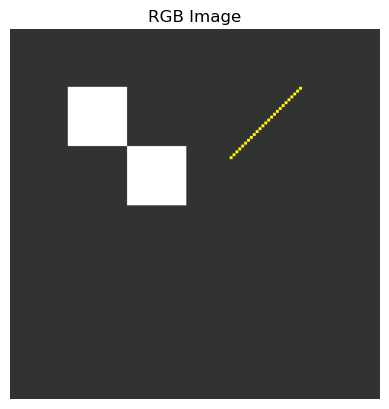

In [17]:
plt.imsave("input.png", rgb_img)
print("已儲存 input.png")
plt.imshow(rgb_img)
plt.title("RGB Image")
plt.axis("off")
plt.show()

In [18]:
# 讀取 txt 檔格式
def load_hex_tokens(path):
    vals = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            for p in line.strip().split():
                vals.append(int(p, 16))
    return vals

def load_rgb_txt(path, h=256, w=256):
    """
    讀取 input_rgb*.txt
    每個 token 視為 0x00RRGGBB
    """
    vals = load_hex_tokens(path)
    if len(vals) != h * w:
        raise ValueError(f"像素數量錯誤，預期 {h*w}，實際 {len(vals)}")

    arr = np.array(vals, dtype=np.uint32).reshape(h, w)

    r = ((arr >> 16) & 0xFF).astype(np.uint8)
    g = ((arr >> 8)  & 0xFF).astype(np.uint8)
    b = (arr & 0xFF).astype(np.uint8)

    return np.stack([r, g, b], axis=-1)

def load_packed_txt(path, h=256, w=256):
    """
    讀取 bbox_golden*.txt
    保留每個像素的 32-bit packed 值
    """
    vals = load_hex_tokens(path)
    if len(vals) != h * w:
        raise ValueError(f"像素數量錯誤，預期 {h*w}，實際 {len(vals)}")
    return np.array(vals, dtype=np.uint32).reshape(h, w)

def packed_to_rgb(arr):
    r = ((arr >> 16) & 0xFF).astype(np.uint8)
    g = ((arr >> 8)  & 0xFF).astype(np.uint8)
    b = (arr & 0xFF).astype(np.uint8)
    return np.stack([r, g, b], axis=-1)

In [19]:
# 讀取原始 RGB 與 golden
rgb_img = load_rgb_txt(rgb_path, H, W)
golden_packed = load_packed_txt(golden_path, H, W)
golden_rgb = packed_to_rgb(golden_packed)

print("rgb_img.shape =", rgb_img.shape)
print("golden_packed.shape =", golden_packed.shape)
print("RGB[0,0] =", rgb_img[0, 0])
print("Golden[0,0] =", hex(int(golden_packed[0, 0])))

rgb_img.shape = (256, 256, 3)
golden_packed.shape = (256, 256)
RGB[0,0] = [50 50 50]
Golden[0,0] = 0x323232


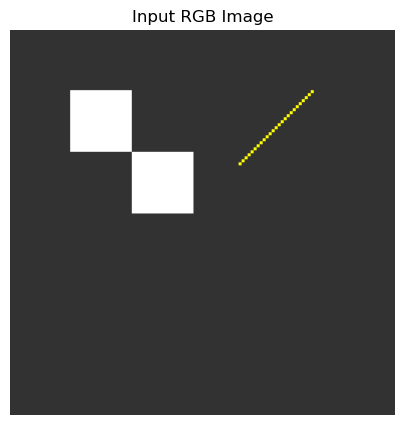

In [22]:
plt.figure(figsize=(5,5))
plt.imshow(rgb_img)
plt.title("Input RGB Image")
plt.axis("off")
plt.show()

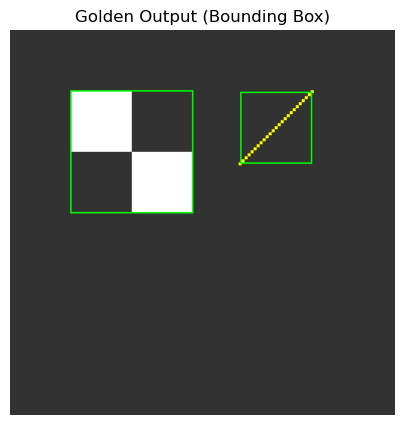

In [23]:
plt.figure(figsize=(5,5))
plt.imshow(golden_rgb)
plt.title("Golden Output (Bounding Box)")
plt.axis("off")
plt.show()

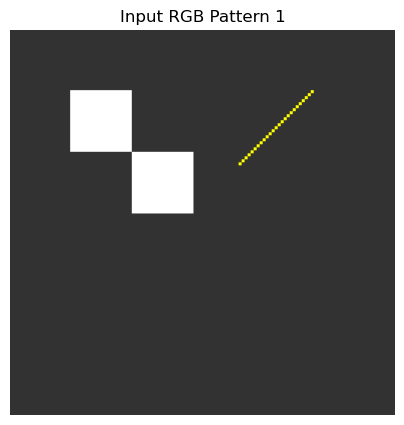

In [24]:
# 顯示原始 RGB 圖
plt.figure(figsize=(5, 5))
plt.imshow(rgb_img)
plt.title(f"Input RGB Pattern {PATTERN_ID}")
plt.axis("off")
plt.show()

gray min/max = 50 255


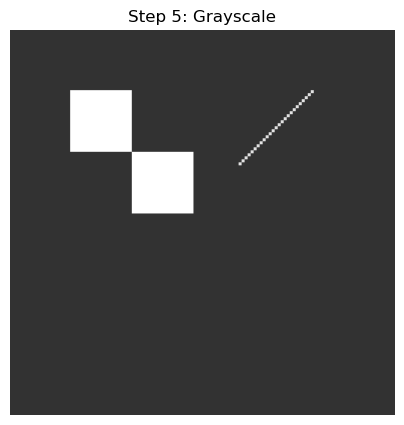

In [25]:
# Cell 5：RGB 轉灰階
def rgb_to_gray(rgb):
    """
    Gray ≈ 0.299R + 0.587G + 0.114B
    使用 np.rint() 做 round to nearest, ties to even
    """
    r = rgb[..., 0].astype(np.float64)
    g = rgb[..., 1].astype(np.float64)
    b = rgb[..., 2].astype(np.float64)

    gray_f = 0.299 * r + 0.587 * g + 0.114 * b
    gray = np.rint(gray_f).astype(np.uint8)
    return gray

gray = rgb_to_gray(rgb_img)

print("gray min/max =", gray.min(), gray.max())

plt.figure(figsize=(5, 5))
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.title("Step 5: Grayscale")
plt.axis("off")
plt.show()

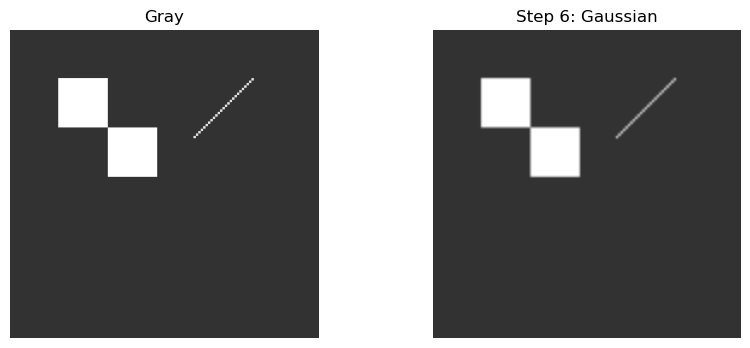

In [26]:
# Cell 6：3x3 Gaussian Filter（Reflect 101）
def gaussian_3x3_reflect101(gray):
    """
    3x3 Gaussian
    kernel =
    1 2 1
    2 4 2   / 16
    1 2 1

    邊界使用 np.pad(..., mode='reflect')
    對應 Reflect 101
    """
    kernel = np.array(
        [[1, 2, 1],
         [2, 4, 2],
         [1, 2, 1]], dtype=np.int32
    )

    padded = np.pad(gray.astype(np.int32), ((1, 1), (1, 1)), mode="reflect")
    out = np.zeros_like(gray, dtype=np.uint8)

    for y in range(gray.shape[0]):
        for x in range(gray.shape[1]):
            win = padded[y:y+3, x:x+3]
            val = np.sum(win * kernel) / 16.0
            out[y, x] = np.rint(val).astype(np.uint8)

    return out

gauss = gaussian_3x3_reflect101(gray)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.title("Gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gauss, cmap="gray", vmin=0, vmax=255)
plt.title("Step 6: Gaussian")
plt.axis("off")
plt.show()

Otsu threshold = 149


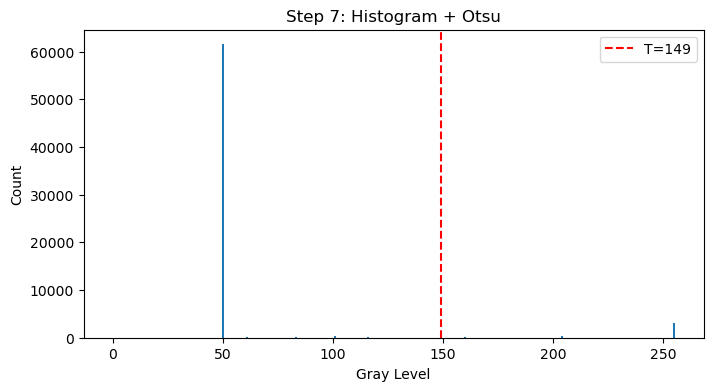

In [27]:
# Cell 7：Histogram + Otsu Threshold
def otsu_threshold(img):
    hist = np.bincount(img.flatten(), minlength=256).astype(np.int64)

    total = img.size
    total_sum = np.dot(np.arange(256, dtype=np.int64), hist)

    best_t = 0
    best_sigma = -1.0

    wb_count = 0
    wb_sum = 0

    for t in range(256):
        wb_count += hist[t]
        wb_sum += t * hist[t]
        wf_count = total - wb_count

        if wb_count == 0 or wf_count == 0:
            continue

        mub = wb_sum / wb_count
        muf = (total_sum - wb_sum) / wf_count

        wb = wb_count / total
        wf = wf_count / total

        sigma_b2 = wb * wf * (mub - muf) ** 2

        if sigma_b2 > best_sigma:
            best_sigma = sigma_b2
            best_t = t

    return best_t, hist

otsu_t, hist = otsu_threshold(gauss)
print("Otsu threshold =", otsu_t)

plt.figure(figsize=(8, 4))
plt.bar(np.arange(256), hist, width=1.0)
plt.axvline(otsu_t, color="r", linestyle="--", label=f"T={otsu_t}")
plt.title("Step 7: Histogram + Otsu")
plt.xlabel("Gray Level")
plt.ylabel("Count")
plt.legend()
plt.show()

mask_raw foreground pixels = 3410


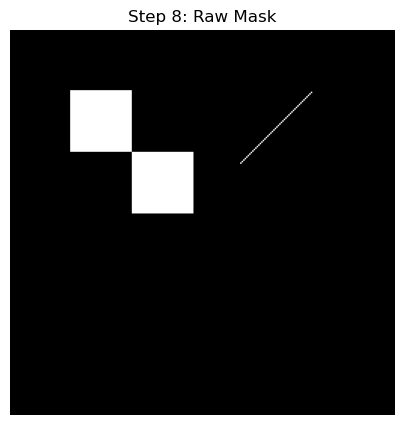

In [28]:
# Cell 8：初始 Mask
mask_raw = (gauss > otsu_t).astype(np.uint8)

print("mask_raw foreground pixels =", int(mask_raw.sum()))

plt.figure(figsize=(5, 5))
plt.imshow(mask_raw, cmap="gray", vmin=0, vmax=1)
plt.title("Step 8: Raw Mask")
plt.axis("off")
plt.show()

foreground ratio = 0.052032470703125
是否反相 = False


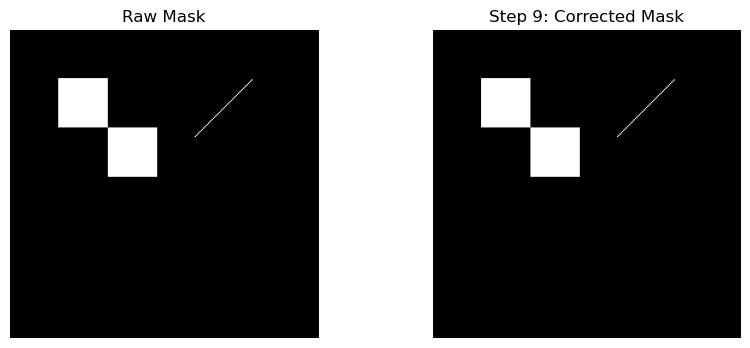

In [29]:
# Cell 9：Auto-Polarity Correction
def auto_polarity_correction(mask_raw, ratio_threshold=0.5):
    """
    若 foreground 比例過大，代表可能把背景當前景
    就做反相
    """
    fg_ratio = mask_raw.mean()
    if fg_ratio > ratio_threshold:
        return 1 - mask_raw, True, fg_ratio
    return mask_raw.copy(), False, fg_ratio

mask, inverted, fg_ratio = auto_polarity_correction(mask_raw, ratio_threshold=0.5)

print("foreground ratio =", fg_ratio)
print("是否反相 =", inverted)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(mask_raw, cmap="gray", vmin=0, vmax=1)
plt.title("Raw Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray", vmin=0, vmax=1)
plt.title("Step 9: Corrected Mask")
plt.axis("off")
plt.show()

Step 10: Label count = 2


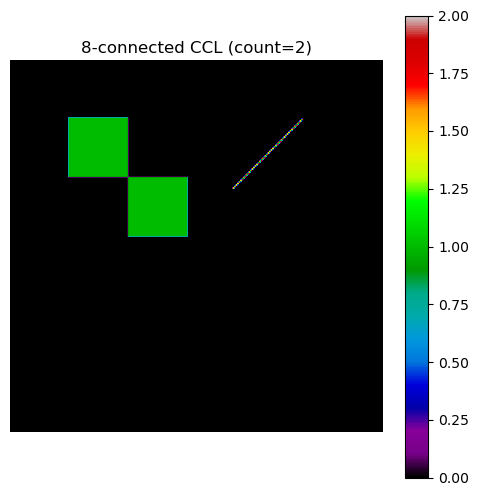

In [30]:
# Cell 10：8-connected CCL
def ccl_8_connected(mask):
    h, w = mask.shape
    labels = np.zeros((h, w), dtype=np.int32)
    visited = np.zeros((h, w), dtype=bool)

    label = 0

    nbrs = [
        (-1, -1), (-1, 0), (-1, 1),
        ( 0, -1),          ( 0, 1),
        ( 1, -1), ( 1, 0), ( 1, 1),
    ]

    for y in range(h):
        for x in range(w):
            if mask[y, x] == 0 or visited[y, x]:
                continue

            label += 1
            q = deque([(y, x)])
            visited[y, x] = True
            labels[y, x] = label

            while q:
                cy, cx = q.popleft()
                for dy, dx in nbrs:
                    ny, nx = cy + dy, cx + dx
                    if 0 <= ny < h and 0 <= nx < w:
                        if mask[ny, nx] == 1 and not visited[ny, nx]:
                            visited[ny, nx] = True
                            labels[ny, nx] = label
                            q.append((ny, nx))

    return labels, label

labels, label_count = ccl_8_connected(mask)
print("Step 10: Label count =", label_count)

plt.figure(figsize=(6, 6))
plt.imshow(labels, cmap="nipy_spectral")
plt.title(f"8-connected CCL (count={label_count})")
plt.axis("off")
plt.colorbar()
plt.show()

In [31]:
# Cell 11：Bounding Box + Border Object Rejection
def compute_bboxes(labels, label_count):
    h, w = labels.shape
    bboxes = {}

    for lb in range(1, label_count + 1):
        ys, xs = np.where(labels == lb)
        if len(xs) == 0:
            continue

        xmin = int(xs.min())
        xmax = int(xs.max())
        ymin = int(ys.min())
        ymax = int(ys.max())

        touch_border = (xmin == 0) or (xmax == w - 1) or (ymin == 0) or (ymax == h - 1)

        bboxes[lb] = {
            "xmin": xmin,
            "xmax": xmax,
            "ymin": ymin,
            "ymax": ymax,
            "touch_border": touch_border
        }

    return bboxes

bboxes = compute_bboxes(labels, label_count)
bboxes_valid = {lb: box for lb, box in bboxes.items() if not box["touch_border"]}

print("所有 bbox 數量 =", len(bboxes))
print("有效 bbox 數量 =", len(bboxes_valid))

for k in list(bboxes_valid.keys())[:10]:
    print(f"Label {k}: {bboxes_valid[k]}")

所有 bbox 數量 = 2
有效 bbox 數量 = 2
Label 1: {'xmin': 40, 'xmax': 121, 'ymin': 40, 'ymax': 121, 'touch_border': False}
Label 2: {'xmin': 153, 'xmax': 200, 'ymin': 41, 'ymax': 88, 'touch_border': False}


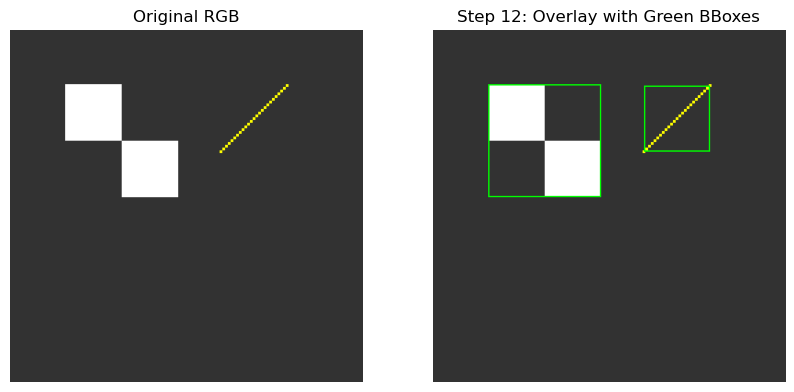

In [32]:
# Cell 12：畫綠色 Bounding Box Overlay
def overlay_bboxes(rgb, bboxes_valid):
    out = rgb.copy()

    for _, box in bboxes_valid.items():
        xmin, xmax = box["xmin"], box["xmax"]
        ymin, ymax = box["ymin"], box["ymax"]

        out[ymin, xmin:xmax+1] = GREEN
        out[ymax, xmin:xmax+1] = GREEN
        out[ymin:ymax+1, xmin] = GREEN
        out[ymin:ymax+1, xmax] = GREEN

    return out

overlay_rgb = overlay_bboxes(rgb_img, bboxes_valid)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlay_rgb)
plt.title("Step 12: Overlay with Green BBoxes")
plt.axis("off")
plt.show()

In [33]:
# Cell 13：轉回 32-bit packed 格式
def rgb_to_packed(rgb):
    r = rgb[..., 0].astype(np.uint32)
    g = rgb[..., 1].astype(np.uint32)
    b = rgb[..., 2].astype(np.uint32)
    return (r << 16) | (g << 8) | b

overlay_packed = rgb_to_packed(overlay_rgb)
print("overlay_packed[0,0] =", hex(int(overlay_packed[0,0])))

overlay_packed[0,0] = 0x323232


In [34]:
# Cell 14：與 golden 逐像素比較
equal_map = (overlay_packed == golden_packed)
correct_pixels = int(equal_map.sum())
total_pixels = equal_map.size
accuracy = correct_pixels / total_pixels

print("Correct pixels =", correct_pixels)
print("Total pixels   =", total_pixels)
print("Different pix  =", total_pixels - correct_pixels)
print(f"Accuracy       = {accuracy * 100:.6f}%")

Correct pixels = 65536
Total pixels   = 65536
Different pix  = 0
Accuracy       = 100.000000%


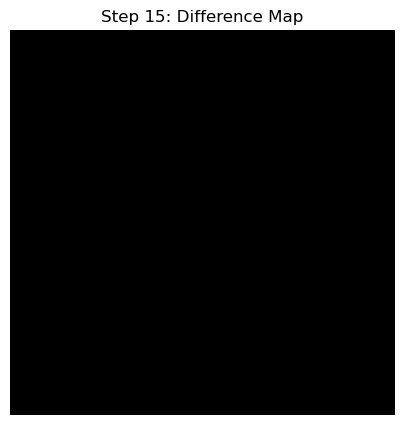

In [35]:
# Cell 15：顯示差異圖
diff_map = (~equal_map).astype(np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(diff_map, cmap="gray", vmin=0, vmax=1)
plt.title("Step 15: Difference Map")
plt.axis("off")
plt.show()

In [36]:
# Cell 16：輸出 Python 結果成 txt
def save_packed_txt(path, arr):
    with open(path, "w", encoding="utf-8") as f:
        for row in arr:
            f.write(" ".join(f"{int(v):08x}" for v in row) + "\n")

out_path = f"py_overlay_pattern{PATTERN_ID}.txt"
save_packed_txt(out_path, overlay_packed)
print("已輸出：", out_path)

已輸出： py_overlay_pattern1.txt


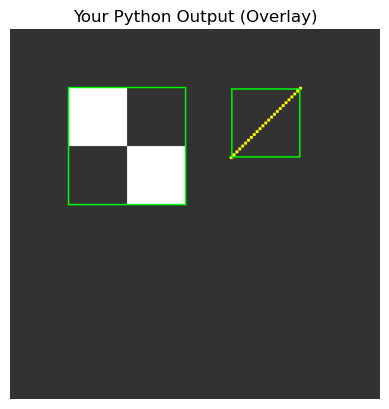

In [39]:
# 讀回 txt → 顯示成圖片（最重要🔥）
def load_packed_txt(path, h=256, w=256):
    data = []
    with open(path) as f:
        for line in f:
            data.extend([int(x,16) for x in line.split()])
    return np.array(data, dtype=np.uint32).reshape(h,w)

def packed_to_rgb(arr):
    r = ((arr >> 16) & 0xFF).astype(np.uint8)
    g = ((arr >> 8)  & 0xFF).astype(np.uint8)
    b = (arr & 0xFF).astype(np.uint8)
    return np.stack([r,g,b], axis=-1)

# 讀回你剛存的檔案
py_packed = load_packed_txt(out_path)
py_rgb = packed_to_rgb(py_packed)

# 顯示
plt.imshow(py_rgb)
plt.title("Your Python Output (Overlay)")
plt.axis("off")
plt.show()

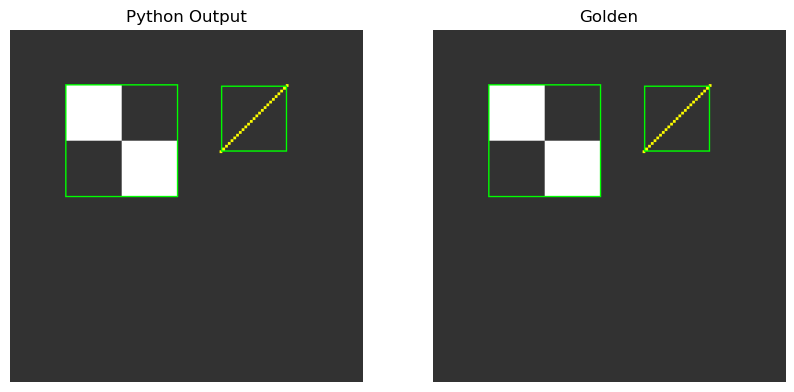

In [40]:
# 和 golden 並排比較（超關鍵）
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(py_rgb)
plt.title("Python Output")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(golden_rgb)
plt.title("Golden")
plt.axis("off")

plt.show()

In [41]:
# ✅ 方法 3：直接算差異（再驗證一次）
diff = (py_packed != golden_packed)

print("不同 pixel 數 =", diff.sum())

不同 pixel 數 = 0


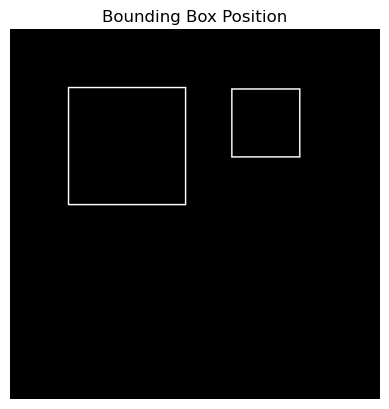

In [42]:
# ✅ 方法 4：只看綠色框位置（debug 超好用）
green_mask = (py_rgb[:,:,0]==0) & (py_rgb[:,:,1]==255) & (py_rgb[:,:,2]==0)

plt.imshow(green_mask, cmap='gray')
plt.title("Bounding Box Position")
plt.axis("off")
plt.show()

In [43]:
# ✅ 方法 5：印幾個 pixel（超低階 debug）
for i in range(5):
    print(hex(int(py_packed[i,0])), hex(int(golden_packed[i,0])))

0x323232 0x323232
0x323232 0x323232
0x323232 0x323232
0x323232 0x323232
0x323232 0x323232


In [44]:
# ✅ 一鍵轉 PNG（直接可用）
import numpy as np
import matplotlib.pyplot as plt

H, W = 256, 256

def load_packed_txt(path):
    data = []
    with open(path) as f:
        for line in f:
            data.extend([int(x,16) for x in line.split()])
    return np.array(data, dtype=np.uint32).reshape(H,W)

def packed_to_rgb(arr):
    r = ((arr >> 16) & 0xFF).astype(np.uint8)
    g = ((arr >> 8)  & 0xFF).astype(np.uint8)
    b = (arr & 0xFF).astype(np.uint8)
    return np.stack([r,g,b], axis=-1)

# 👉 你的 txt 檔
txt_path = "py_overlay_pattern1.txt"

# 讀取
packed = load_packed_txt(txt_path)
rgb = packed_to_rgb(packed)

# 存成 PNG
plt.imsave("output.png", rgb)

print("✅ 已轉成 output.png（可以直接用 Windows 打開）")

✅ 已轉成 output.png（可以直接用 Windows 打開）


Input : input_rgb1.txt
Golden: bbox_golden1.txt
Input exists ? True
Golden exists? True
Otsu threshold         = 149
Auto polarity inverted = False
Foreground ratio       = 0.052032470703125
Label count            = 2
All bbox count         = 2
Valid bbox count       = 2
Pixel accuracy         = 100.000000%


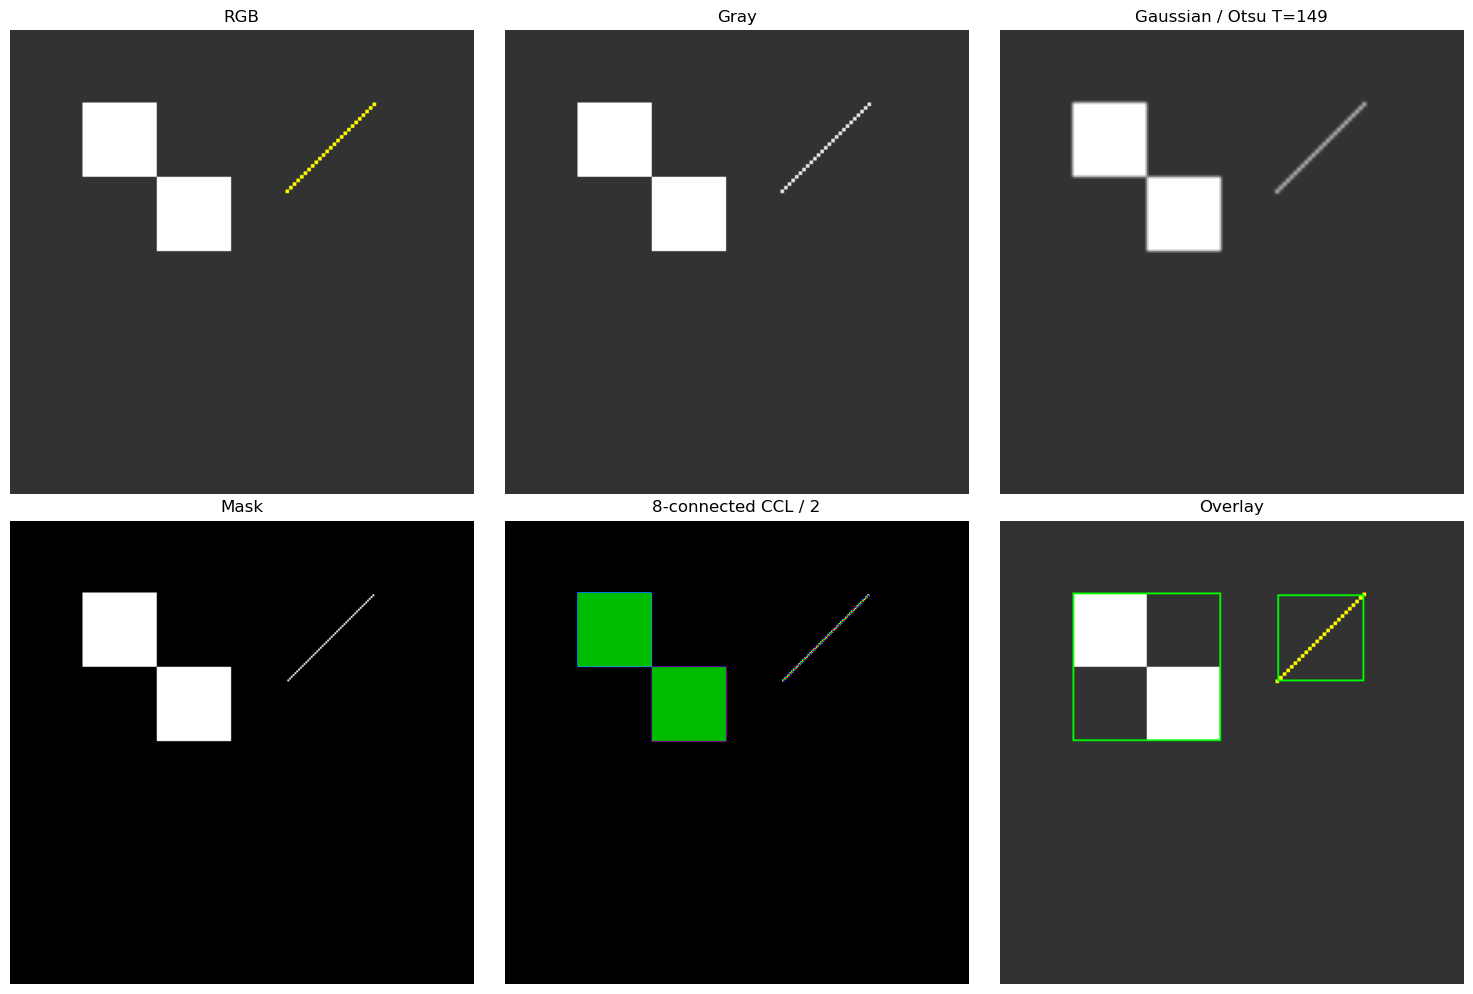

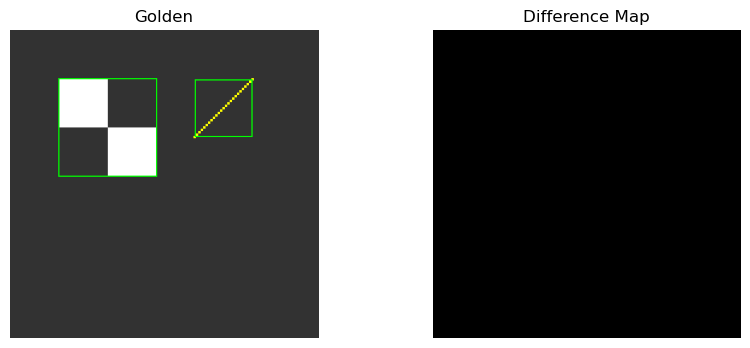

已輸出：py_overlay_pattern1.txt
已輸出：py_overlay_pattern1.png
已輸出：golden_pattern1.png
已輸出：input_pattern1.png


In [46]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# =========================================================
# 基本設定
# =========================================================
H, W = 256, 256
GREEN = np.array([0, 255, 0], dtype=np.uint8)

# 改成 1 / 2 / 3 / 4
PATTERN_ID = 1

rgb_path = Path(f"input_rgb{PATTERN_ID}.txt")
golden_path = Path(f"bbox_golden{PATTERN_ID}.txt")

print("Input :", rgb_path)
print("Golden:", golden_path)
print("Input exists ?", rgb_path.exists())
print("Golden exists?", golden_path.exists())


# =========================================================
# 讀檔工具
# =========================================================
def load_hex_tokens(path):
    """
    讀取 txt 檔中所有 16 進位 token，回傳 int list
    """
    vals = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            for p in line.strip().split():
                vals.append(int(p, 16))
    return vals


def load_rgb_txt(path, h=256, w=256):
    """
    讀取 input_rgb*.txt
    每個 token 視為 0x00RRGGBB
    輸出 shape = (H, W, 3)
    """
    vals = load_hex_tokens(path)
    if len(vals) != h * w:
        raise ValueError(f"像素數量錯誤，預期 {h*w}，實際 {len(vals)}")

    arr = np.array(vals, dtype=np.uint32).reshape(h, w)

    r = ((arr >> 16) & 0xFF).astype(np.uint8)
    g = ((arr >> 8)  & 0xFF).astype(np.uint8)
    b = (arr & 0xFF).astype(np.uint8)

    return np.stack([r, g, b], axis=-1)


def load_packed_txt(path, h=256, w=256):
    """
    讀取 bbox_golden*.txt 或 Python 輸出的 packed txt
    每個 token 視為 32-bit packed RGB
    輸出 shape = (H, W)
    """
    vals = load_hex_tokens(path)
    if len(vals) != h * w:
        raise ValueError(f"像素數量錯誤，預期 {h*w}，實際 {len(vals)}")

    return np.array(vals, dtype=np.uint32).reshape(h, w)


def packed_to_rgb(arr):
    """
    32-bit packed -> RGB 圖
    """
    r = ((arr >> 16) & 0xFF).astype(np.uint8)
    g = ((arr >> 8)  & 0xFF).astype(np.uint8)
    b = (arr & 0xFF).astype(np.uint8)
    return np.stack([r, g, b], axis=-1)


def rgb_to_packed(rgb):
    """
    RGB -> 32-bit packed
    0x00RRGGBB
    """
    r = rgb[..., 0].astype(np.uint32)
    g = rgb[..., 1].astype(np.uint32)
    b = rgb[..., 2].astype(np.uint32)
    return (r << 16) | (g << 8) | b


# =========================================================
# 影像處理
# =========================================================
def rgb_to_gray(rgb):
    """
    Gray ≈ 0.299R + 0.587G + 0.114B
    round to nearest, ties to even
    """
    r = rgb[..., 0].astype(np.float64)
    g = rgb[..., 1].astype(np.float64)
    b = rgb[..., 2].astype(np.float64)

    gray_f = 0.299 * r + 0.587 * g + 0.114 * b
    gray = np.rint(gray_f).astype(np.uint8)
    return gray


def gaussian_3x3_reflect101(gray):
    """
    3x3 Gaussian
    kernel =
    1 2 1
    2 4 2   / 16
    1 2 1

    邊界使用 Reflect 101
    """
    kernel = np.array(
        [[1, 2, 1],
         [2, 4, 2],
         [1, 2, 1]], dtype=np.int32
    )

    padded = np.pad(gray.astype(np.int32), ((1, 1), (1, 1)), mode="reflect")
    out = np.zeros_like(gray, dtype=np.uint8)

    for y in range(gray.shape[0]):
        for x in range(gray.shape[1]):
            win = padded[y:y+3, x:x+3]
            val = np.sum(win * kernel) / 16.0
            out[y, x] = np.rint(val).astype(np.uint8)

    return out


def otsu_threshold(img):
    """
    計算 Otsu threshold
    回傳:
        best_t, hist
    """
    hist = np.bincount(img.flatten(), minlength=256).astype(np.int64)

    total = img.size
    total_sum = np.dot(np.arange(256, dtype=np.int64), hist)

    best_t = 0
    best_sigma = -1.0

    wb_count = 0
    wb_sum = 0

    for t in range(256):
        wb_count += hist[t]
        wb_sum += t * hist[t]
        wf_count = total - wb_count

        if wb_count == 0 or wf_count == 0:
            continue

        mub = wb_sum / wb_count
        muf = (total_sum - wb_sum) / wf_count

        wb = wb_count / total
        wf = wf_count / total

        sigma_b2 = wb * wf * (mub - muf) ** 2

        if sigma_b2 > best_sigma:
            best_sigma = sigma_b2
            best_t = t

    return best_t, hist


def auto_polarity_correction(mask_raw, ratio_threshold=0.5):
    """
    若 foreground 比例過大，代表可能把背景當前景，則做反相
    """
    fg_ratio = mask_raw.mean()
    if fg_ratio > ratio_threshold:
        return 1 - mask_raw, True, fg_ratio
    return mask_raw.copy(), False, fg_ratio


# =========================================================
# CCL / BBox
# =========================================================
def ccl_8_connected(mask):
    """
    8-connected CCL
    回傳:
        labels, label_count
    """
    h, w = mask.shape
    labels = np.zeros((h, w), dtype=np.int32)
    visited = np.zeros((h, w), dtype=bool)

    label = 0

    nbrs = [
        (-1, -1), (-1, 0), (-1, 1),
        ( 0, -1),          ( 0, 1),
        ( 1, -1), ( 1, 0), ( 1, 1),
    ]

    for y in range(h):
        for x in range(w):
            if mask[y, x] == 0 or visited[y, x]:
                continue

            label += 1
            q = deque([(y, x)])
            visited[y, x] = True
            labels[y, x] = label

            while q:
                cy, cx = q.popleft()
                for dy, dx in nbrs:
                    ny, nx = cy + dy, cx + dx
                    if 0 <= ny < h and 0 <= nx < w:
                        if mask[ny, nx] == 1 and not visited[ny, nx]:
                            visited[ny, nx] = True
                            labels[ny, nx] = label
                            q.append((ny, nx))

    return labels, label


def compute_bboxes(labels, label_count):
    """
    對每個 label 計算:
        xmin, xmax, ymin, ymax, touch_border
    """
    h, w = labels.shape
    bboxes = {}

    for lb in range(1, label_count + 1):
        ys, xs = np.where(labels == lb)
        if len(xs) == 0:
            continue

        xmin = int(xs.min())
        xmax = int(xs.max())
        ymin = int(ys.min())
        ymax = int(ys.max())

        touch_border = (xmin == 0) or (xmax == w - 1) or (ymin == 0) or (ymax == h - 1)

        bboxes[lb] = {
            "xmin": xmin,
            "xmax": xmax,
            "ymin": ymin,
            "ymax": ymax,
            "touch_border": touch_border,
        }

    return bboxes


def overlay_bboxes(rgb, bboxes_valid):
    """
    在原圖上畫綠色 bounding box
    """
    out = rgb.copy()

    for _, box in bboxes_valid.items():
        xmin, xmax = box["xmin"], box["xmax"]
        ymin, ymax = box["ymin"], box["ymax"]

        # 上下邊
        out[ymin, xmin:xmax+1] = GREEN
        out[ymax, xmin:xmax+1] = GREEN

        # 左右邊
        out[ymin:ymax+1, xmin] = GREEN
        out[ymin:ymax+1, xmax] = GREEN

    return out


# =========================================================
# 輸出工具
# =========================================================
def save_packed_txt(path, arr):
    with open(path, "w", encoding="utf-8") as f:
        for row in arr:
            f.write(" ".join(f"{int(v):08x}" for v in row) + "\n")


def save_rgb_png(path, rgb):
    plt.imsave(path, rgb)


# =========================================================
# 完整 pipeline
# =========================================================
def run_full_lab7_pipeline(rgb_path, golden_path, show=True, save_outputs=True):
    # 1. 讀圖
    rgb_img = load_rgb_txt(rgb_path, H, W)
    golden_packed = load_packed_txt(golden_path, H, W)
    golden_rgb = packed_to_rgb(golden_packed)

    # 2. RGB -> Gray
    gray = rgb_to_gray(rgb_img)

    # 3. Gaussian
    gauss = gaussian_3x3_reflect101(gray)

    # 4. Otsu
    otsu_t, hist = otsu_threshold(gauss)

    # 5. Threshold + Auto-polarity
    mask_raw = (gauss > otsu_t).astype(np.uint8)
    mask, inverted, fg_ratio = auto_polarity_correction(mask_raw, ratio_threshold=0.5)

    # 6. 8-connected CCL
    labels, label_count = ccl_8_connected(mask)

    # 7. Bounding boxes
    bboxes = compute_bboxes(labels, label_count)

    # 8. Border object rejection
    bboxes_valid = {lb: box for lb, box in bboxes.items() if not box["touch_border"]}

    # 9. Overlay 綠框
    overlay_rgb = overlay_bboxes(rgb_img, bboxes_valid)
    overlay_packed = rgb_to_packed(overlay_rgb)

    # 10. 與 golden 比較
    equal_map = (overlay_packed == golden_packed)
    accuracy = equal_map.mean()
    diff_map = (~equal_map).astype(np.uint8)

    if show:
        print("Otsu threshold         =", otsu_t)
        print("Auto polarity inverted =", inverted)
        print("Foreground ratio       =", fg_ratio)
        print("Label count            =", label_count)
        print("All bbox count         =", len(bboxes))
        print("Valid bbox count       =", len(bboxes_valid))
        print(f"Pixel accuracy         = {accuracy * 100:.6f}%")

        plt.figure(figsize=(15, 10))

        plt.subplot(2, 3, 1)
        plt.imshow(rgb_img)
        plt.title("RGB")
        plt.axis("off")

        plt.subplot(2, 3, 2)
        plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
        plt.title("Gray")
        plt.axis("off")

        plt.subplot(2, 3, 3)
        plt.imshow(gauss, cmap="gray", vmin=0, vmax=255)
        plt.title(f"Gaussian / Otsu T={otsu_t}")
        plt.axis("off")

        plt.subplot(2, 3, 4)
        plt.imshow(mask, cmap="gray", vmin=0, vmax=1)
        plt.title("Mask")
        plt.axis("off")

        plt.subplot(2, 3, 5)
        plt.imshow(labels, cmap="nipy_spectral")
        plt.title(f"8-connected CCL / {label_count}")
        plt.axis("off")

        plt.subplot(2, 3, 6)
        plt.imshow(overlay_rgb)
        plt.title("Overlay")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(golden_rgb)
        plt.title("Golden")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(diff_map, cmap="gray", vmin=0, vmax=1)
        plt.title("Difference Map")
        plt.axis("off")
        plt.show()

    if save_outputs:
        base = f"pattern{PATTERN_ID}"
        save_packed_txt(f"py_overlay_{base}.txt", overlay_packed)
        save_rgb_png(f"py_overlay_{base}.png", overlay_rgb)
        save_rgb_png(f"golden_{base}.png", golden_rgb)
        save_rgb_png(f"input_{base}.png", rgb_img)

        print(f"已輸出：py_overlay_{base}.txt")
        print(f"已輸出：py_overlay_{base}.png")
        print(f"已輸出：golden_{base}.png")
        print(f"已輸出：input_{base}.png")

    return {
        "rgb": rgb_img,
        "golden_rgb": golden_rgb,
        "gray": gray,
        "gauss": gauss,
        "otsu_t": otsu_t,
        "hist": hist,
        "mask_raw": mask_raw,
        "mask": mask,
        "inverted": inverted,
        "fg_ratio": fg_ratio,
        "labels": labels,
        "label_count": label_count,
        "bboxes": bboxes,
        "bboxes_valid": bboxes_valid,
        "overlay_rgb": overlay_rgb,
        "overlay_packed": overlay_packed,
        "golden_packed": golden_packed,
        "accuracy": accuracy,
        "equal_map": equal_map,
        "diff_map": diff_map,
    }


# =========================================================
# 執行單一 pattern
# =========================================================
result = run_full_lab7_pipeline(rgb_path, golden_path, show=True, save_outputs=True)

In [47]:
for pid in [1, 2, 3, 4]:
    PATTERN_ID = pid
    rgb_path = Path(f"input_rgb{PATTERN_ID}.txt")
    golden_path = Path(f"bbox_golden{PATTERN_ID}.txt")

    print("=" * 60)
    print(f"Running Pattern {PATTERN_ID}")
    res = run_full_lab7_pipeline(rgb_path, golden_path, show=False, save_outputs=False)
    print(
        f"P{PATTERN_ID}: "
        f"T={res['otsu_t']}, "
        f"label_count={res['label_count']}, "
        f"valid_bbox={len(res['bboxes_valid'])}, "
        f"acc={res['accuracy'] * 100:.6f}%"
    )

Running Pattern 1
P1: T=149, label_count=2, valid_bbox=2, acc=100.000000%
Running Pattern 2
P2: T=80, label_count=194, valid_bbox=179, acc=99.414062%
Running Pattern 3
P3: T=107, label_count=19, valid_bbox=12, acc=99.954224%
Running Pattern 4
P4: T=163, label_count=358, valid_bbox=338, acc=99.325562%


Running Pattern 1
P1: T=149, label_count=2, valid_bbox=2, acc=100.000000%


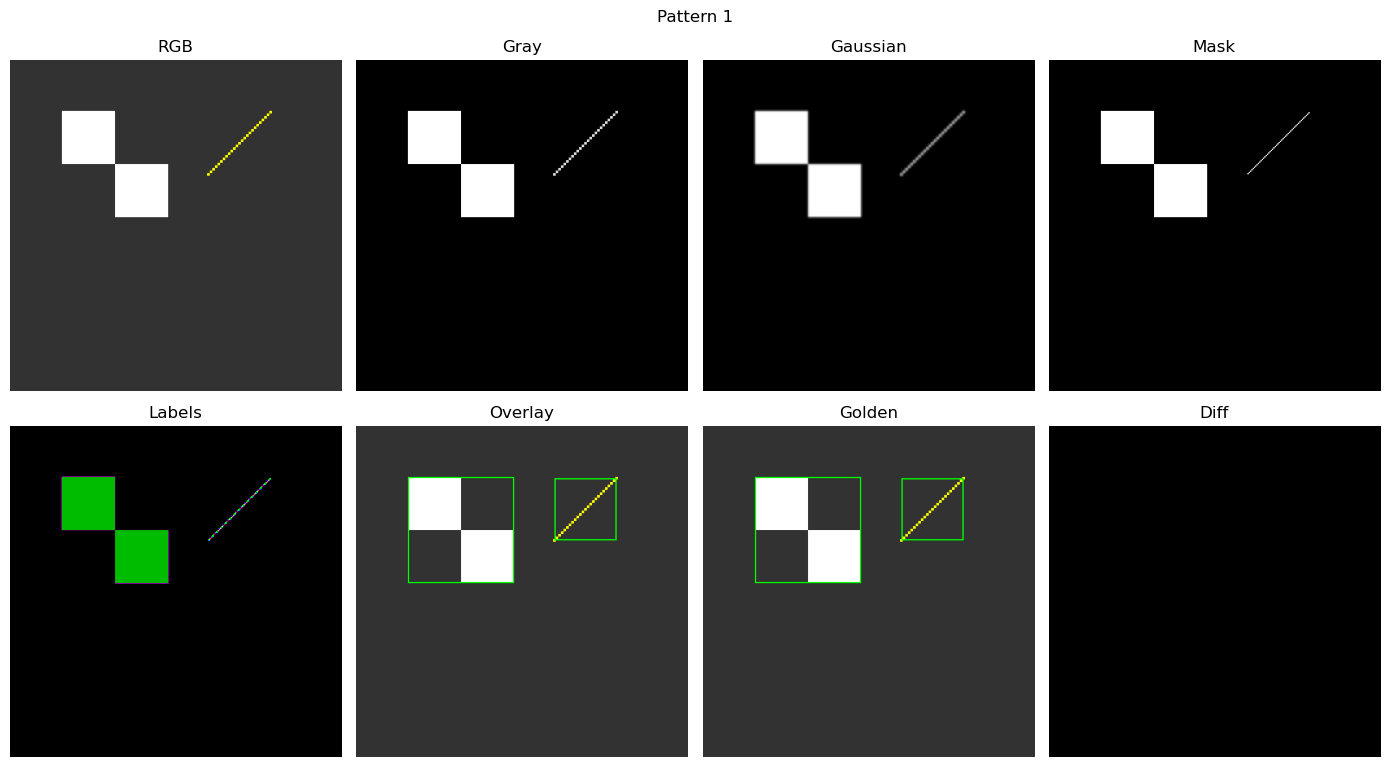

Running Pattern 2
P2: T=80, label_count=194, valid_bbox=179, acc=99.414062%


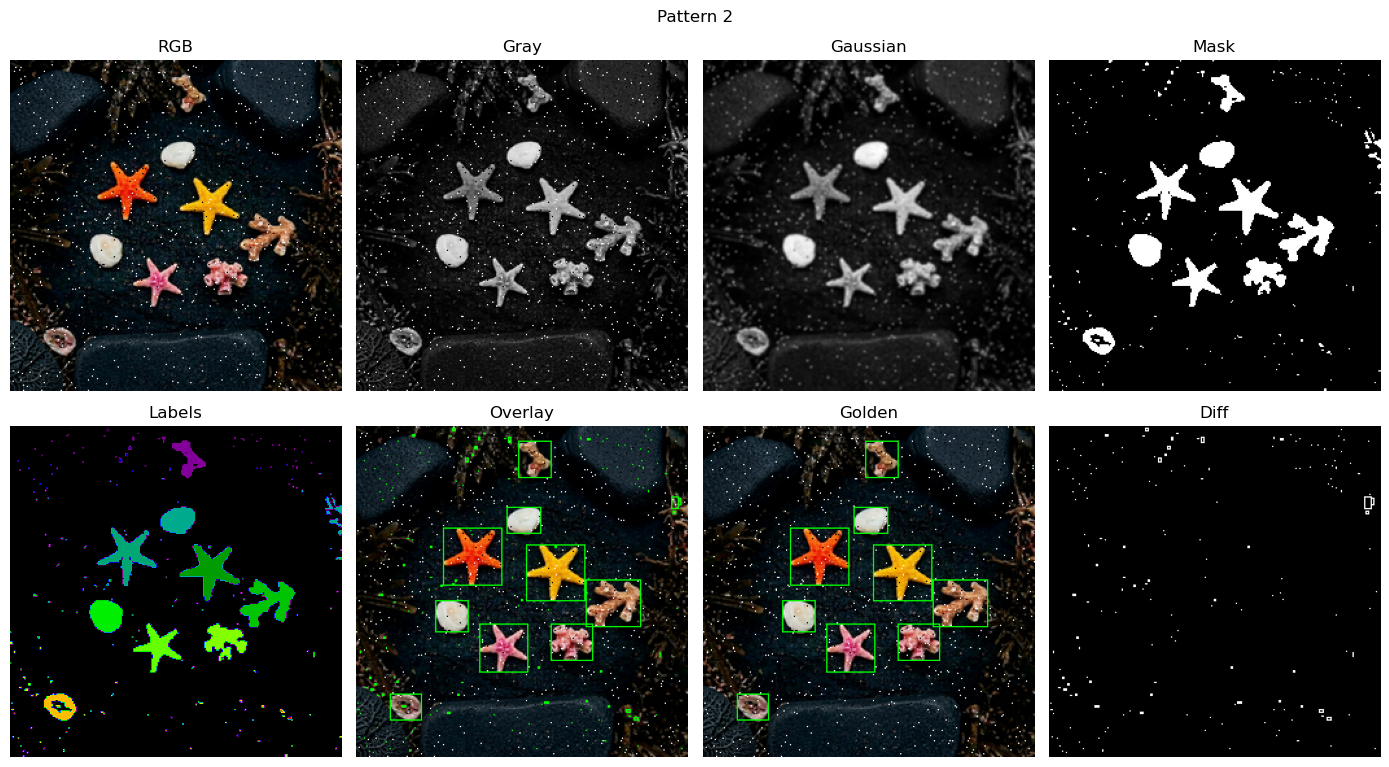

Running Pattern 3
P3: T=107, label_count=19, valid_bbox=12, acc=99.954224%


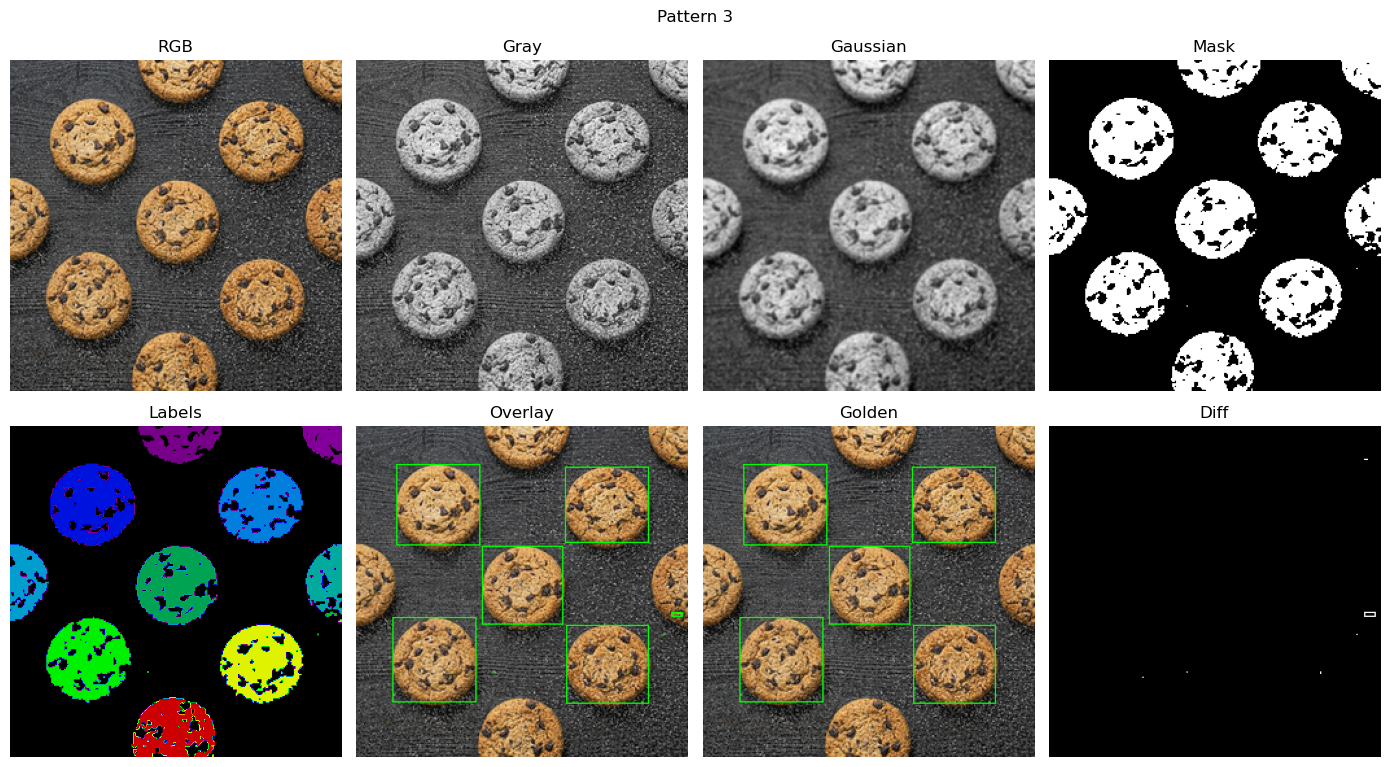

Running Pattern 4
P4: T=163, label_count=358, valid_bbox=338, acc=99.325562%


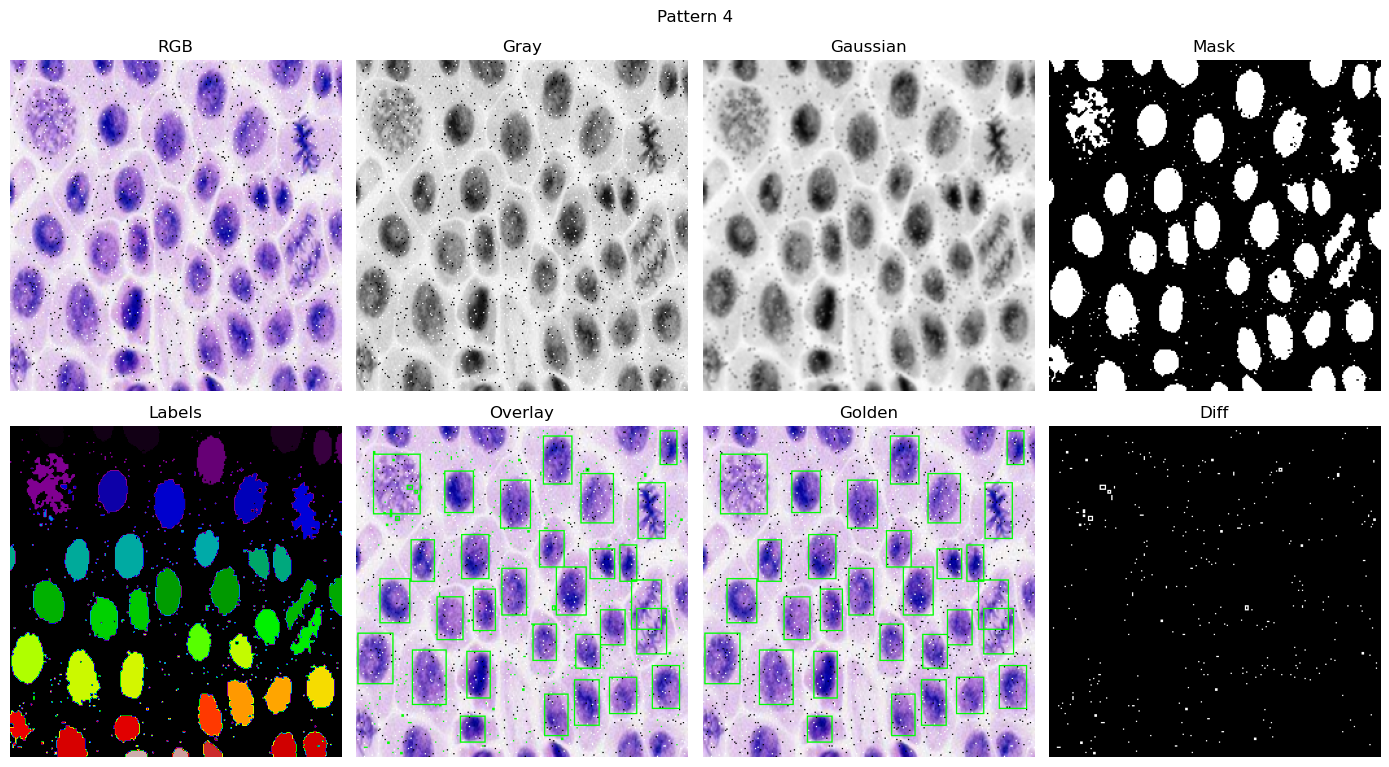

✅ 全部完成！圖片已存到 ./Result/


In [48]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

# 建立資料夾
result_dir = Path("Result")
result_dir.mkdir(exist_ok=True)

for pid in [1, 2, 3, 4]:
    print("=" * 60)
    print(f"Running Pattern {pid}")

    rgb_path = Path(f"input_rgb{pid}.txt")
    golden_path = Path(f"bbox_golden{pid}.txt")

    res = run_full_lab7_pipeline(
        rgb_path,
        golden_path,
        show=False,
        save_outputs=False
    )

    # === 取資料 ===
    rgb = res["rgb"]
    gray = res["gray"]
    gauss = res["gauss"]
    mask = res["mask"]
    labels = res["labels"]
    overlay = res["overlay_rgb"]
    golden = res["golden_rgb"]
    diff = res["diff_map"]

    # === 印結果 ===
    print(
        f"P{pid}: "
        f"T={res['otsu_t']}, "
        f"label_count={res['label_count']}, "
        f"valid_bbox={len(res['bboxes_valid'])}, "
        f"acc={res['accuracy'] * 100:.6f}%"
    )

    # =========================================================
    # 🖼️ 顯示圖片（Jupyter）
    # =========================================================
    plt.figure(figsize=(14,8))

    plt.subplot(2,4,1)
    plt.imshow(rgb)
    plt.title("RGB")
    plt.axis("off")

    plt.subplot(2,4,2)
    plt.imshow(gray, cmap="gray")
    plt.title("Gray")
    plt.axis("off")

    plt.subplot(2,4,3)
    plt.imshow(gauss, cmap="gray")
    plt.title("Gaussian")
    plt.axis("off")

    plt.subplot(2,4,4)
    plt.imshow(mask, cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(2,4,5)
    plt.imshow(labels, cmap="nipy_spectral")
    plt.title("Labels")
    plt.axis("off")

    plt.subplot(2,4,6)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.subplot(2,4,7)
    plt.imshow(golden)
    plt.title("Golden")
    plt.axis("off")

    plt.subplot(2,4,8)
    plt.imshow(diff, cmap="gray", vmin=0, vmax=1)
    plt.title("Diff")
    plt.axis("off")

    plt.suptitle(f"Pattern {pid}")
    plt.tight_layout()
    plt.show()

    # =========================================================
    # 💾 存 PNG 到 Result/
    # =========================================================
    plt.imsave(result_dir / f"P{pid}_input.png", rgb)
    plt.imsave(result_dir / f"P{pid}_gray.png", gray, cmap="gray")
    plt.imsave(result_dir / f"P{pid}_gaussian.png", gauss, cmap="gray")
    plt.imsave(result_dir / f"P{pid}_mask.png", mask, cmap="gray")
    plt.imsave(result_dir / f"P{pid}_labels.png", labels, cmap="nipy_spectral")
    plt.imsave(result_dir / f"P{pid}_overlay.png", overlay)
    plt.imsave(result_dir / f"P{pid}_golden.png", golden)
    plt.imsave(result_dir / f"P{pid}_diff.png", diff, cmap="gray")

print("✅ 全部完成！圖片已存到 ./Result/")

In [45]:
# # Cell 17：包成完整 pipeline 函式
# def run_full_lab7_pipeline(rgb_path, golden_path, show=True):
#     rgb_img = load_rgb_txt(rgb_path, H, W)
#     golden_packed = load_packed_txt(golden_path, H, W)
#     golden_rgb = packed_to_rgb(golden_packed)

#     gray = rgb_to_gray(rgb_img)
#     gauss = gaussian_3x3_reflect101(gray)
#     otsu_t, hist = otsu_threshold(gauss)

#     mask_raw = (gauss > otsu_t).astype(np.uint8)
#     mask, inverted, fg_ratio = auto_polarity_correction(mask_raw, ratio_threshold=0.5)

#     labels, label_count = ccl_8_connected(mask)
#     bboxes = compute_bboxes(labels, label_count)
#     bboxes_valid = {lb: box for lb, box in bboxes.items() if not box["touch_border"]}

#     overlay_rgb = overlay_bboxes(rgb_img, bboxes_valid)
#     overlay_packed = rgb_to_packed(overlay_rgb)

#     equal_map = (overlay_packed == golden_packed)
#     accuracy = equal_map.mean()

#     if show:
#         print("Otsu threshold         =", otsu_t)
#         print("Auto polarity inverted =", inverted)
#         print("Foreground ratio       =", fg_ratio)
#         print("Label count            =", label_count)
#         print("All bbox count         =", len(bboxes))
#         print("Valid bbox count       =", len(bboxes_valid))
#         print(f"Pixel accuracy         = {accuracy * 100:.6f}%")

#     return {
#         "rgb": rgb_img,
#         "golden_rgb": golden_rgb,
#         "gray": gray,
#         "gauss": gauss,
#         "otsu_t": otsu_t,
#         "mask": mask,
#         "labels": labels,
#         "label_count": label_count,
#         "bboxes": bboxes,
#         "bboxes_valid": bboxes_valid,
#         "overlay_rgb": overlay_rgb,
#         "overlay_packed": overlay_packed,
#         "accuracy": accuracy,
#         "diff_map": (~equal_map).astype(np.uint8),
#     }

# result = run_full_lab7_pipeline(rgb_path, golden_path, show=True)

TypeError: load_packed_txt() takes 1 positional argument but 3 were given

In [38]:
# Cell 18：一次跑 1~4 pattern
for pid in [1, 2, 3, 4]:
    rp = Path(f"input_rgb{pid}.txt")
    gp = Path(f"bbox_golden{pid}.txt")
    if rp.exists() and gp.exists():
        res = run_full_lab7_pipeline(rp, gp, show=False)
        print(
            f"P{pid}: "
            f"T={res['otsu_t']}, "
            f"label_count={res['label_count']}, "
            f"valid_bbox={len(res['bboxes_valid'])}, "
            f"acc={res['accuracy'] * 100:.6f}%"
        )

P1: T=149, label_count=2, valid_bbox=2, acc=100.000000%
P2: T=80, label_count=194, valid_bbox=179, acc=99.414062%
P3: T=107, label_count=19, valid_bbox=12, acc=99.954224%
P4: T=163, label_count=358, valid_bbox=338, acc=99.325562%
